In [7]:
import numpy as np

def gradient_descent(x, y):
    m_curr = b_curr = 0
    iterations = 1000
    n = len(x)
    learning_rate = 0.08
    
    # List to store history of each iteration
    history = []

    for i in range(iterations):
        y_predicted = m_curr * x + b_curr
        cost = (1/n) * sum([val**2 for val in (y-y_predicted)])
        
        # Derivatives
        md = -(2/n) * sum(x * (y - y_predicted))
        bd = -(2/n) * sum(y - y_predicted)
        
        # Update weights
        m_curr = m_curr - learning_rate * md
        b_curr = b_curr - learning_rate * bd
        
        # Save to history
        history.append((m_curr, b_curr, cost, i))
        
    return history

# Input data
x = np.array([1, 2, 3, 4, 5])           # x values
y = np.array([5, 7, 9, 11, 13])         # y values

# Run gradient descent
results = gradient_descent(x, y)

# Print First 5 Iterations
print("--- FIRST 5 ITERATIONS ---")
for r in results[:5]:
    print(f"m: {r[0]:.4f}, b: {r[1]:.4f}, cost: {r[2]:.4f}, iteration: {r[3]}")

print("\n" + "-" * 40 + "\n")

# Print Last 5 Iterations
print("--- LAST 5 ITERATIONS ---")
for r in results[-5:]:
    print(f"m: {r[0]:.4f}, b: {r[1]:.4f}, cost: {r[2]:.10f}, iteration: {r[3]}")

--- FIRST 5 ITERATIONS ---
m: 4.9600, b: 1.4400, cost: 89.0000, iteration: 0
m: 0.4992, b: 0.2688, cost: 71.1056, iteration: 1
m: 4.4516, b: 1.4262, cost: 56.8298, iteration: 2
m: 0.8922, b: 0.5012, cost: 45.4397, iteration: 3
m: 4.0413, b: 1.4328, cost: 36.3509, iteration: 4

----------------------------------------

--- LAST 5 ITERATIONS ---
m: 2.0000, b: 3.0000, cost: 0.0000000000, iteration: 995
m: 2.0000, b: 3.0000, cost: 0.0000000000, iteration: 996
m: 2.0000, b: 3.0000, cost: 0.0000000000, iteration: 997
m: 2.0000, b: 3.0000, cost: 0.0000000000, iteration: 998
m: 2.0000, b: 3.0000, cost: 0.0000000000, iteration: 999


First 5 iterations: The cost starts high (e.g., 89.0), and $m$ and $b$ shift aggressively.

Last 5 iterations: The cost drops down extremely close to 0, 

and $m$ settles perfectly at 2.0 while $b$ settles at 3.0 (which perfectly matches the equation

$y = 2x + 3$ = **Cost** for our dataset).

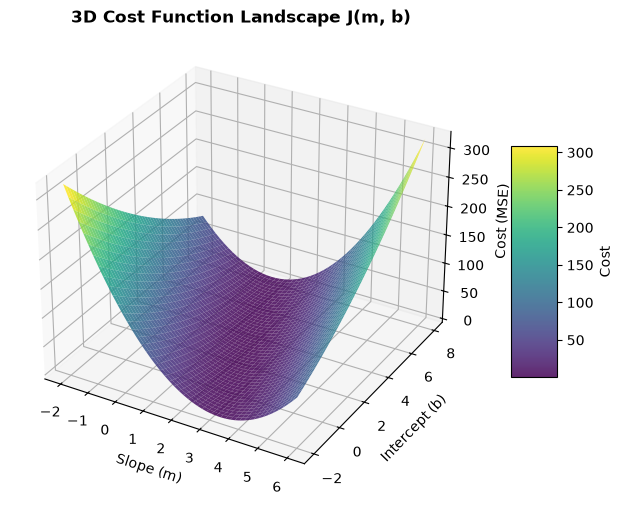

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define ranges for slope (m) and intercept (b)
m_vals = np.linspace(-2, 6, 50)
b_vals = np.linspace(-2, 8, 50)
M, B = np.meshgrid(m_vals, b_vals)

# 2. Your dataset
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 7, 9, 11, 13])

# 3. Calculate Cost (MSE) for every combination of m and b
Cost = np.zeros(M.shape)
for i in range(len(m_vals)):
    for j in range(len(b_vals)):
        m = M[i, j]
        b = B[i, j]
        y_pred = m * x + b
        Cost[i, j] = np.mean((y - y_pred)**2)

# 4. Plot the 3D Surface
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(M, B, Cost, cmap='viridis', edgecolor='none', alpha=0.85)

ax.set_title('3D Cost Function Landscape J(m, b)', fontsize=12, fontweight='bold')
ax.set_xlabel('Slope (m)')
ax.set_ylabel('Intercept (b)')
ax.set_zlabel('Cost (MSE)')
fig.colorbar(surf, shrink=0.5, aspect=5, label='Cost')

plt.show()

What this 3D graph shows:The Bowl Shape: Gradient descent acts like a ball placed anywhere 

on the outer rim of this bowl.The Bottom (Minimum): The dark purple center at $m = 2$ and $b = 3$ is 

where the error (cost) is zero. Gradient descent stops moving once it rolls right down to this exact bottom point!